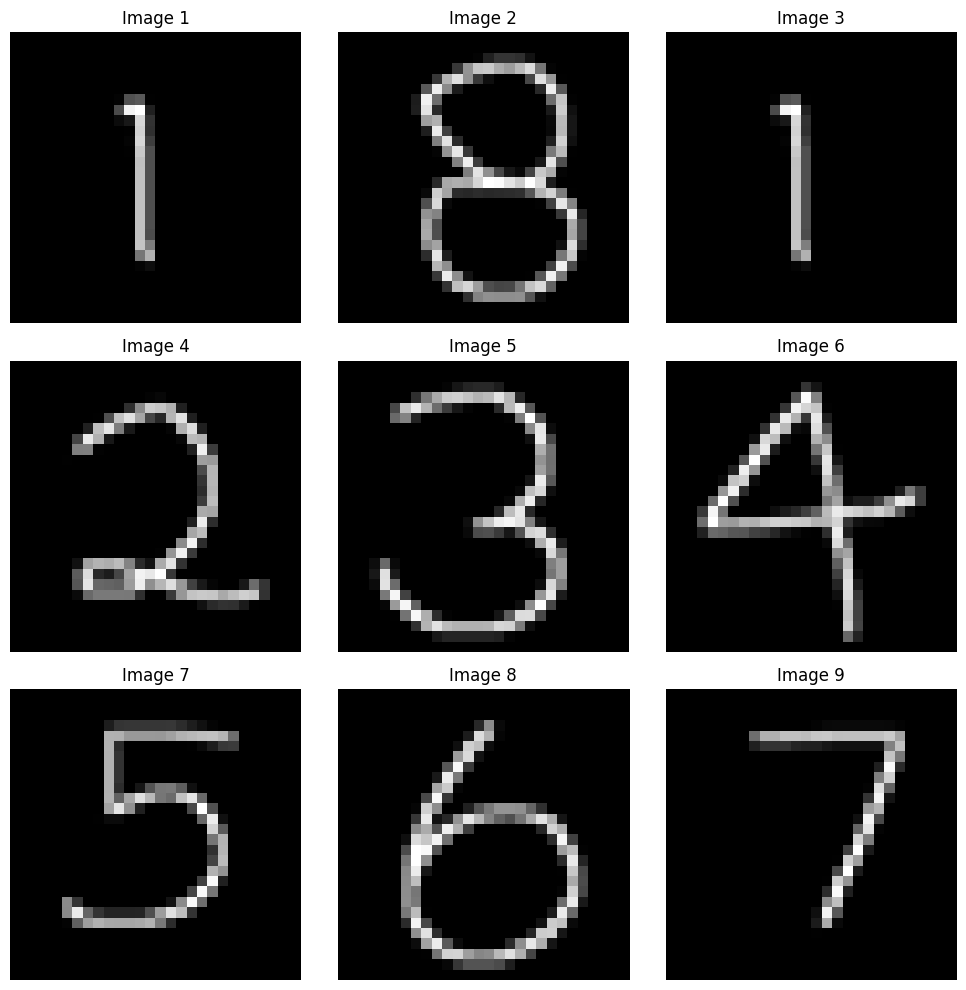

In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

image_files = [f"Picture{i}.png.jpeg" for i in range(1, 10)]

plt.figure(figsize=(10, 10))
for idx, img_file in enumerate(image_files):
    img = Image.open(img_file).convert('L')
    img = img.resize((28, 28))
    img_array = np.array(img) / 255.0

    plt.subplot(3, 3, idx + 1)
    plt.imshow(img_array, cmap='gray')
    plt.title(f"Image {idx+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [ ]:
# 1. Load the Dataset directly from Keras
# This replaces the need for 'train.csv' or local image folders
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
# 2. Preprocessing
# Reshape to include the channel dimension (28, 28, 1) and normalize to [0, 1]
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1)).astype('float32') / 255
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1)).astype('float32') / 255

print(f"Training shape: {x_train.shape}")
print(f"Testing shape: {x_test.shape}")

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


In [ ]:
# 3. Model Creation
model = models.Sequential([
    # Convolutional Layer
    layers.Conv2D(28, kernel_size=(3,3), input_shape=(28, 28, 1), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    
    # Flattening for Dense Layers
    layers.Flatten(),
    
    # Hidden Layer with Dropout to prevent overfitting
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    
    # Output Layer (10 classes for digits 0-9)
    layers.Dense(10, activation='softmax')
])

In [ ]:
# 4. Compile the Model
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 28)     │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 28)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4732)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       605,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 607,394 (2.32 MB)

 Trainable params: 607,394 (2.32 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 5. Train the Model
# 10 epochs is usually sufficient for >98% accuracy on MNIST
history = model.fit(x_train, y_train, 
                    epochs=10, 
                    validation_data=(x_test, y_test), 
                    batch_size=32
                   )



Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9381 - loss: 0.2021 - val_accuracy: 0.9764 - val_loss: 0.0694
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9760 - loss: 0.0798 - val_accuracy: 0.9809 - val_loss: 0.0548
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9817 - loss: 0.0573 - val_accuracy: 0.9838 - val_loss: 0.0469
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9866 - loss: 0.0435 - val_accuracy: 0.9859 - val_loss: 0.0420
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9885 - loss: 0.0353 - val_accuracy: 0.9875 - val_loss: 0.0390
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9905 - loss: 0.0280 - val_accuracy: 0.9870 - val_loss: 0.0393
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9920 - loss: 0.0248 - val_accuracy: 0.9874 - val_loss: 0.0400
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9933 - loss: 0.0197 

In [ ]:
# 6. Evaluate the Model
accuracy = model.evaluate(x_test, y_test)[1]
print(f"Test Accuracy: {accuracy:.4f}")
# 7. Predict on Custom Image
def predict_custom_image(image_path, model):
    # Load and preprocess the image
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    img = img.resize((28, 28))  # Resize to 28x28
    img_array = np.array(img).reshape(1, 28, 28, 1).astype('float32') / 255  # Normalize
    
    # Predict the digit
    prediction = model.predict(img_array)
    predicted_digit = np.argmax(prediction)
    
    print(f"Predicted digit: {predicted_digit}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9878 - loss: 0.0432
Test Accuracy: 0.9878


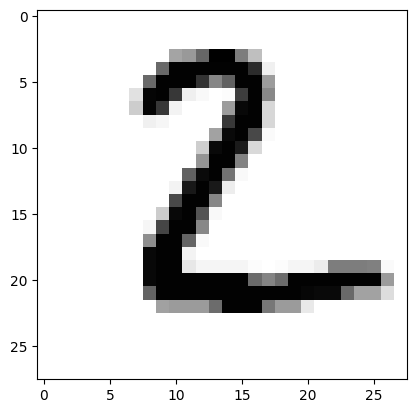

In [ ]:
# 6. Testing/Visualization
image_index = 1
plt.imshow(x_test[image_index].reshape(28, 28), cmap='Greys')
plt.show()

In [ ]:
pred = model.predict(x_test[image_index].reshape(1, 28, 28, 1))
print(f"Predicted Digit: {pred.argmax()}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted Digit: 2


In [ ]:
accuracy = model.evaluate(x_test, y_test)[1]
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9878 - loss: 0.0432
Test Accuracy: 0.9878


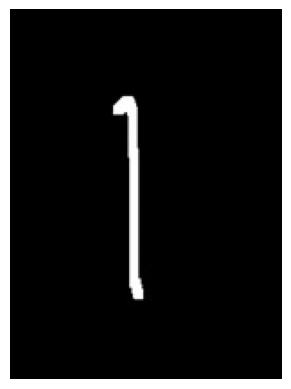

In [ ]:
from PIL import Image,ImageOps

img=Image.open("Picture1.png.jpeg").convert('L')

#img=ImageOps.invert(img)
plt.imshow(img, cmap='gray')
plt.axis('off')
img.show()

In [ ]:
img=img.resize((28,28))
img_array = np.array(img)/ 255
img_araray=img_array.reshape(1,28,28,1)

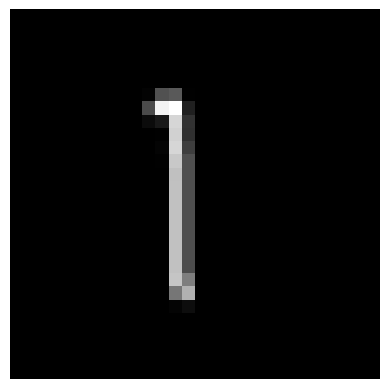

In [ ]:
#img=ImageOps.invert(img)
plt.imshow(img_array, cmap='gray')
plt.axis('off')
img.show()

In [ ]:
pred = model.predict(img_araray)
digit = np.argmax(pred)
print("Predicted Digit:", digit)
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Digit: 1


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Digit: 8


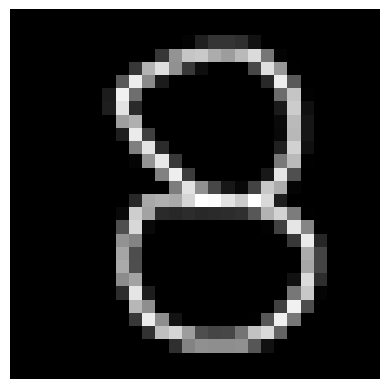

In [ ]:
img=Image.open("Picture2.png.jpeg").convert('L')

#img=ImageOps.invert(img)
plt.imshow(img, cmap='gray')
plt.axis('off')
img.show()

img=img.resize((28,28))
img_array = np.array(img)/ 255
img_araray=img_array.reshape(1,28,28,1)


#img=ImageOps.invert(img)
plt.imshow(img_array, cmap='gray')
plt.axis('off')

pred = model.predict(img_araray)
digit = np.argmax(pred)
print("Predicted Digit:", digit)
    


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Digit: 1


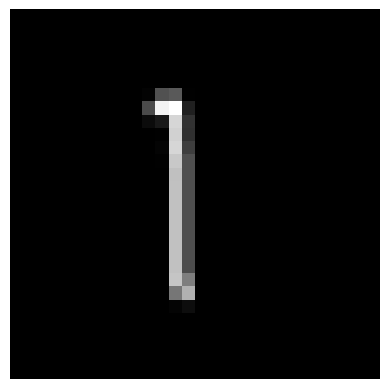

In [ ]:
img=Image.open("Picture3.png.jpeg").convert('L')

#img=ImageOps.invert(img)
plt.imshow(img, cmap='gray')
plt.axis('off')
img.show()

img=img.resize((28,28))
img_array = np.array(img)/ 255
img_araray=img_array.reshape(1,28,28,1)


#img=ImageOps.invert(img)
plt.imshow(img_array, cmap='gray')
plt.axis('off')

pred = model.predict(img_araray)
digit = np.argmax(pred)
print("Predicted Digit:", digit)
    

In [ ]:
pred = model.predict(img_araray)
digit = np.argmax(pred)
print("Predicted Digit:", digit)
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Digit: 1


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted Digit: 2


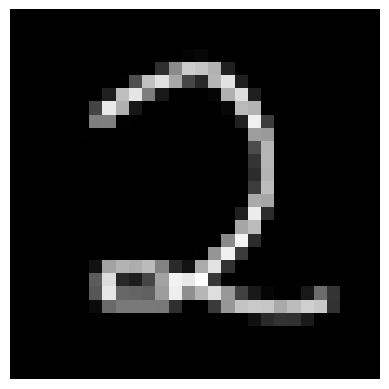

In [ ]:
img=Image.open("Picture4.png.jpeg").convert('L')

#img=ImageOps.invert(img)
plt.imshow(img, cmap='gray')
plt.axis('off')
img.show()

img=img.resize((28,28))
img_array = np.array(img)/ 255
img_araray=img_array.reshape(1,28,28,1)


#img=ImageOps.invert(img)
plt.imshow(img_array, cmap='gray')
plt.axis('off')

pred = model.predict(img_araray)
digit = np.argmax(pred)
print("Predicted Digit:", digit)

In [ ]:
pred = model.predict(img_araray)
digit = np.argmax(pred)
print("Predicted Digit:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted Digit: 2


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predicted Digit: 3


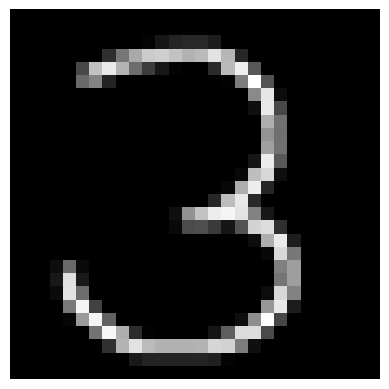

In [ ]:
img=Image.open("Picture5.png.jpeg").convert('L')

#img=ImageOps.invert(img)
plt.imshow(img, cmap='gray')
plt.axis('off')
img.show()

img=img.resize((28,28))
img_array = np.array(img)/ 255
img_araray=img_array.reshape(1,28,28,1)


#img=ImageOps.invert(img)
plt.imshow(img_array, cmap='gray')
plt.axis('off')

pred = model.predict(img_araray)
digit = np.argmax(pred)
print("Predicted Digit:", digit)

In [ ]:
pred = model.predict(img_araray)
digit = np.argmax(pred)
print("Predicted Digit:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Predicted Digit: 3


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Predicted Digit: 4


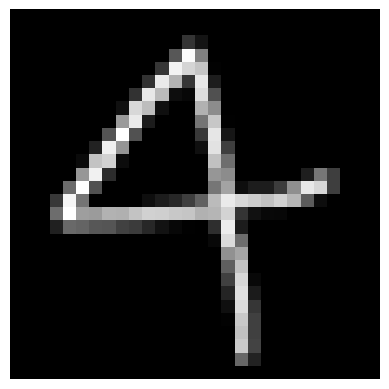

In [ ]:
img=Image.open("Picture6.png.jpeg").convert('L')

#img=ImageOps.invert(img)
plt.imshow(img, cmap='gray')
plt.axis('off')
img.show()

img=img.resize((28,28))
img_array = np.array(img)/ 255
img_araray=img_array.reshape(1,28,28,1)


#img=ImageOps.invert(img)
plt.imshow(img_array, cmap='gray')
plt.axis('off')

pred = model.predict(img_araray)
digit = np.argmax(pred)
print("Predicted Digit:", digit)

In [ ]:
pred = model.predict(img_araray)
digit = np.argmax(pred)
print("Predicted Digit:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Predicted Digit: 4


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Predicted Digit: 5


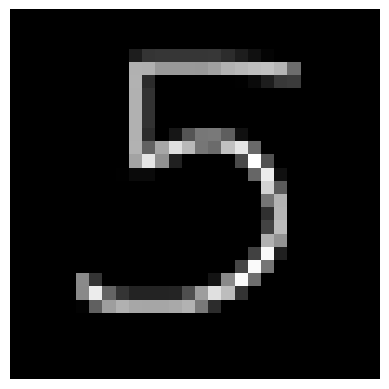

In [ ]:
img=Image.open("Picture7.png.jpeg").convert('L')

#img=ImageOps.invert(img)
plt.imshow(img, cmap='gray')
plt.axis('off')
img.show()

img=img.resize((28,28))
img_array = np.array(img)/ 255
img_araray=img_array.reshape(1,28,28,1)


#img=ImageOps.invert(img)
plt.imshow(img_array, cmap='gray')
plt.axis('off')

pred = model.predict(img_araray)
digit = np.argmax(pred)
print("Predicted Digit:", digit)

In [ ]:
pred = model.predict(img_araray)
digit = np.argmax(pred)
print("Predicted Digit:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicted Digit: 5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Predicted Digit: 6


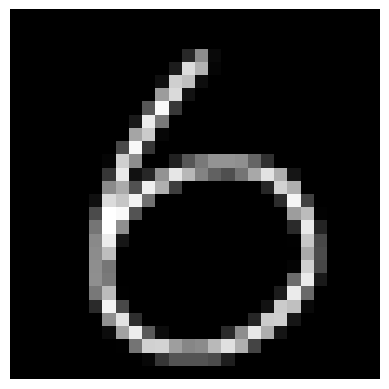

In [ ]:
img=Image.open("Picture8.png.jpeg").convert('L')

#img=ImageOps.invert(img)
plt.imshow(img, cmap='gray')
plt.axis('off')
img.show()

img=img.resize((28,28))
img_array = np.array(img)/ 255
img_araray=img_array.reshape(1,28,28,1)


#img=ImageOps.invert(img)
plt.imshow(img_array, cmap='gray')
plt.axis('off')

pred = model.predict(img_araray)
digit = np.argmax(pred)
print("Predicted Digit:", digit)

In [ ]:
pred = model.predict(img_araray)
digit = np.argmax(pred)
print("Predicted Digit:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
Predicted Digit: 6


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
Predicted Digit: 7


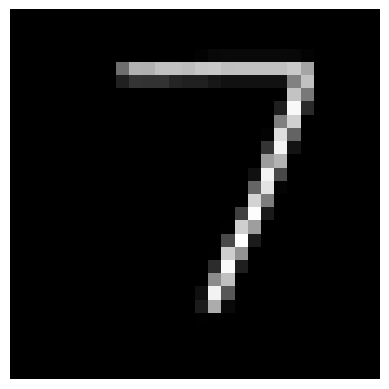

In [ ]:
img=Image.open("Picture9.png.jpeg").convert('L')

#img=ImageOps.invert(img)
plt.imshow(img, cmap='gray')
plt.axis('off')
img.show()

img=img.resize((28,28))
img_array = np.array(img)/ 255
img_araray=img_array.reshape(1,28,28,1)


#img=ImageOps.invert(img)
plt.imshow(img_array, cmap='gray')
plt.axis('off')

pred = model.predict(img_araray)
digit = np.argmax(pred)
print("Predicted Digit:", digit)

In [ ]:
pred = model.predict(img_araray)
digit = np.argmax(pred)
print("Predicted Digit:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Predicted Digit: 7


In [ ]:
import pickle
with open ("mnist_cnn.h5", "wb") as f:
    pickle.dump(model, f)
